# Student Baseline Training — ResNet-20 on CIFAR-100 (No Distillation)

This notebook trains the student network **without any knowledge distillation** — using only standard cross-entropy loss on hard labels. This establishes the baseline performance of a compact model trained in isolation.

The gap between this baseline and the teacher (72.95%) quantifies the performance cost of model compression without distillation. Subsequent notebooks will show how distillation closes this gap.

**Dataset:** CIFAR-100 — 60,000 images across 100 fine-grained classes  
**Architecture:** ResNet-20 (He et al., 2016) — 0.27M parameters  
**Teacher Accuracy:** 72.95% (ResNet-110, trained in notebook 01)  
**Expected Baseline Accuracy:** ~68-69%

## 1. Mount Google Drive

All checkpoints and results are saved to the same Drive folder used in notebook 01.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

DRIVE_BASE  = '/content/drive/MyDrive/kd_project'
CKPT_DIR    = f'{DRIVE_BASE}/checkpoints'
RESULTS_DIR = f'{DRIVE_BASE}/results'

os.makedirs(CKPT_DIR,    exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f'Drive mounted.')
print(f'Checkpoints → {CKPT_DIR}')
print(f'Results     → {RESULTS_DIR}')

Mounted at /content/drive
Drive mounted.
Checkpoints → /content/drive/MyDrive/kd_project/checkpoints
Results     → /content/drive/MyDrive/kd_project/results


## 2. Environment Setup

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
else:
    print('WARNING: No GPU detected. Go to Runtime > Change runtime type > T4 GPU.')

Device : cuda
GPU    : Tesla T4


## 3. Data Loading and Preprocessing

Identical transforms to notebook 01 — same dataset, same normalization, same augmentation. Keeping the data pipeline consistent ensures that any accuracy difference between teacher and student is due to model capacity, not data handling.

In [3]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5071, 0.4867, 0.4408),
                         std=(0.2675, 0.2565, 0.2761))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5071, 0.4867, 0.4408),
                         std=(0.2675, 0.2565, 0.2761))
])

train_dataset = torchvision.datasets.CIFAR100(root='./data', train=True,
                                               download=True, transform=train_transform)
test_dataset  = torchvision.datasets.CIFAR100(root='./data', train=False,
                                               download=True, transform=test_transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128,
                                            shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=128,
                                            shuffle=False, num_workers=2, pin_memory=True)

print(f'Train samples : {len(train_dataset):,}')
print(f'Test samples  : {len(test_dataset):,}')
print(f'Classes       : {len(train_dataset.classes)}')

100%|██████████| 169M/169M [00:03<00:00, 43.3MB/s]


Train samples : 50,000
Test samples  : 10,000
Classes       : 100


## 4. Model Architecture — ResNet-20

ResNet-20 uses the same residual block design as ResNet-110 but with only 3 blocks per stage instead of 18, resulting in 20 layers and ~0.27M parameters — roughly 6× fewer than the teacher.

This architectural difference is the sole reason for the accuracy gap between teacher and student. The distillation experiments in subsequent notebooks address this gap without changing the architecture.

In [4]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1    = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                                  stride=stride, padding=1, bias=False)
        self.bn1      = nn.BatchNorm2d(out_channels)
        self.relu     = nn.ReLU(inplace=True)
        self.conv2    = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                                  stride=1, padding=1, bias=False)
        self.bn2      = nn.BatchNorm2d(out_channels)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out  = self.relu(self.bn1(self.conv1(x)))
        out  = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return self.relu(out)


class ResNet_CIFAR(nn.Module):
    def __init__(self, block, num_blocks, num_classes=100):
        super(ResNet_CIFAR, self).__init__()
        self.in_channels = 16
        self.conv1       = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1         = nn.BatchNorm2d(16)
        self.relu        = nn.ReLU(inplace=True)
        self.layer1      = self._make_layer(block, 16, num_blocks[0], stride=1)
        self.layer2      = self._make_layer(block, 32, num_blocks[1], stride=2)
        self.layer3      = self._make_layer(block, 64, num_blocks[2], stride=2)
        self.avgpool     = nn.AdaptiveAvgPool2d((1, 1))
        self.fc          = nn.Linear(64 * block.expansion, num_classes)
        self._initialize_weights()

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers  = []
        for s in strides:
            layers.append(block(self.in_channels, out_channels, s))
            self.in_channels = out_channels * block.expansion
        return nn.Sequential(*layers)

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        return self.fc(out)


def ResNet20(num_classes=100):
    # 3 blocks × 3 stages × 2 layers + 2 = 20 layers, ~0.27M parameters
    return ResNet_CIFAR(BasicBlock, [3, 3, 3], num_classes)


student      = ResNet20(num_classes=100).to(device)
total_params = sum(p.numel() for p in student.parameters())
print(f'ResNet-20 initialized — {total_params:,} parameters ({total_params/1e6:.2f}M)')
print(f'Teacher parameters    : 1.74M')
print(f'Compression ratio     : {1.74 / (total_params/1e6):.1f}x fewer parameters')

ResNet-20 initialized — 278,324 parameters (0.28M)
Teacher parameters    : 1.74M
Compression ratio     : 6.3x fewer parameters


## 5. Training Configuration

We use the same optimizer and learning rate schedule as the teacher to ensure a fair comparison. Any accuracy difference is attributable solely to model capacity, not training procedure.

In [5]:
NUM_EPOCHS    = 100
LEARNING_RATE = 0.1
MOMENTUM      = 0.9
WEIGHT_DECAY  = 5e-4

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(student.parameters(), lr=LEARNING_RATE,
                      momentum=MOMENTUM, weight_decay=WEIGHT_DECAY, nesterov=True)

scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[50, 75], gamma=0.1)

print(f'Optimizer  : SGD with Nesterov momentum')
print(f'Epochs     : {NUM_EPOCHS}')
print(f'LR schedule: 0.1 → 0.01 (epoch 50) → 0.001 (epoch 75)')

Optimizer  : SGD with Nesterov momentum
Epochs     : 100
LR schedule: 0.1 → 0.01 (epoch 50) → 0.001 (epoch 75)


## 6. Training and Evaluation Functions

In [6]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss   = criterion(logits, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct    += (logits.argmax(dim=1) == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, 100.0 * correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits         = model(images)
            loss           = criterion(logits, labels)
            total_loss += loss.item() * images.size(0)
            correct    += (logits.argmax(dim=1) == labels).sum().item()
            total      += images.size(0)
    return total_loss / total, 100.0 * correct / total


print('Functions defined.')

Functions defined.


## 7. Training Loop

The student is trained for 100 epochs using hard labels only — no teacher involvement. The best checkpoint is saved to Drive and used as the comparison baseline in all distillation notebooks.

In [7]:
train_losses, test_losses = [], []
train_accs,   test_accs   = [], []
best_acc  = 0.0
CKPT_PATH = f'{CKPT_DIR}/student_baseline_resnet20.pth'

print(f'Training ResNet-20 (no distillation) on {device} for {NUM_EPOCHS} epochs...')
print('=' * 70)

start_time = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(student, train_loader, criterion, optimizer, device)
    test_loss,  test_acc  = evaluate(student, test_loader, criterion, device)
    scheduler.step()

    train_losses.append(train_loss);  test_losses.append(test_loss)
    train_accs.append(train_acc);     test_accs.append(test_acc)

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(student.state_dict(), CKPT_PATH)

    elapsed    = (time.time() - start_time) / 60
    current_lr = optimizer.param_groups[0]['lr']
    print(f'Epoch [{epoch:3d}/{NUM_EPOCHS}]  '
          f'Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.2f}%  '
          f'Test Acc: {test_acc:.2f}%  Best: {best_acc:.2f}%  '
          f'LR: {current_lr:.4f}  Elapsed: {elapsed:.1f}m')

elapsed = (time.time() - start_time) / 60
print('=' * 70)
print(f'Training complete — Best Test Accuracy: {best_acc:.2f}% — Total time: {elapsed:.1f} min')
print(f'Checkpoint saved to: {CKPT_PATH}')

Training ResNet-20 (no distillation) on cuda for 100 epochs...
Epoch [  1/100]  Train Loss: 3.9682  Train Acc: 8.15%  Test Acc: 10.31%  Best: 10.31%  LR: 0.1000  Elapsed: 0.5m
Epoch [  2/100]  Train Loss: 3.3202  Train Acc: 18.56%  Test Acc: 19.31%  Best: 19.31%  LR: 0.1000  Elapsed: 0.9m
Epoch [  3/100]  Train Loss: 2.8397  Train Acc: 27.22%  Test Acc: 26.35%  Best: 26.35%  LR: 0.1000  Elapsed: 1.3m
Epoch [  4/100]  Train Loss: 2.5270  Train Acc: 33.55%  Test Acc: 29.62%  Best: 29.62%  LR: 0.1000  Elapsed: 1.7m
Epoch [  5/100]  Train Loss: 2.3149  Train Acc: 37.83%  Test Acc: 33.93%  Best: 33.93%  LR: 0.1000  Elapsed: 2.2m
Epoch [  6/100]  Train Loss: 2.1700  Train Acc: 41.35%  Test Acc: 33.53%  Best: 33.93%  LR: 0.1000  Elapsed: 2.6m
Epoch [  7/100]  Train Loss: 2.0559  Train Acc: 43.86%  Test Acc: 38.42%  Best: 38.42%  LR: 0.1000  Elapsed: 3.0m
Epoch [  8/100]  Train Loss: 1.9779  Train Acc: 45.58%  Test Acc: 39.18%  Best: 39.18%  LR: 0.1000  Elapsed: 3.5m
Epoch [  9/100]  Train Los

## 8. Training Curves

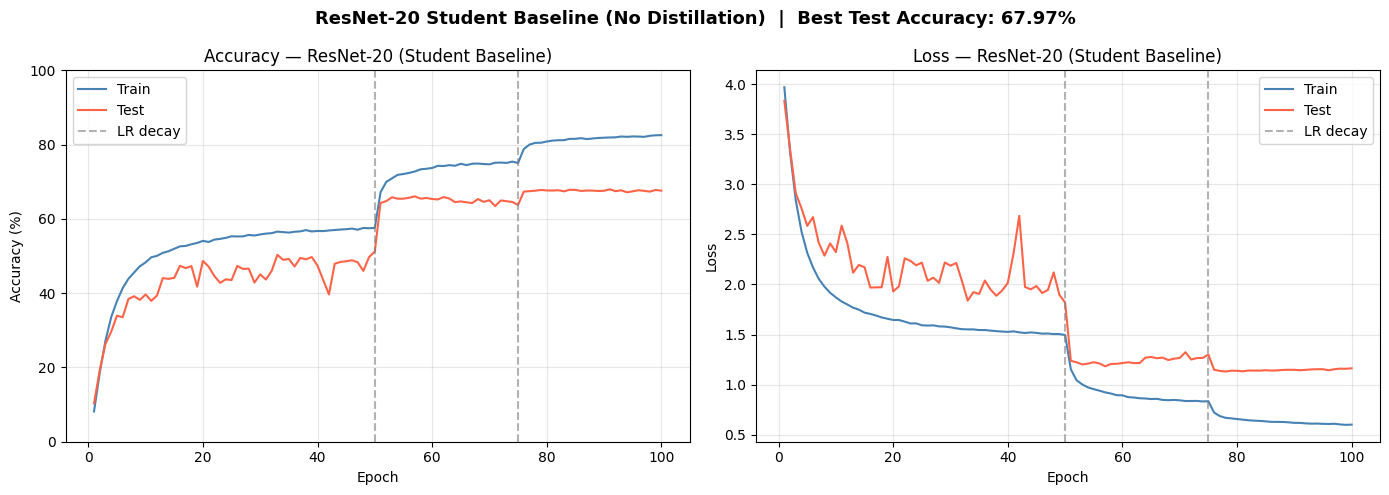

Plot saved to Drive.


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_range    = range(1, NUM_EPOCHS + 1)

ax1.plot(epochs_range, train_accs, label='Train', color='steelblue', linewidth=1.5)
ax1.plot(epochs_range, test_accs,  label='Test',  color='tomato',    linewidth=1.5)
ax1.axvline(x=50, color='gray', linestyle='--', alpha=0.6, label='LR decay')
ax1.axvline(x=75, color='gray', linestyle='--', alpha=0.6)
ax1.set_xlabel('Epoch');  ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Accuracy — ResNet-20 (Student Baseline)')
ax1.legend();  ax1.grid(True, alpha=0.3);  ax1.set_ylim([0, 100])

ax2.plot(epochs_range, train_losses, label='Train', color='steelblue', linewidth=1.5)
ax2.plot(epochs_range, test_losses,  label='Test',  color='tomato',    linewidth=1.5)
ax2.axvline(x=50, color='gray', linestyle='--', alpha=0.6, label='LR decay')
ax2.axvline(x=75, color='gray', linestyle='--', alpha=0.6)
ax2.set_xlabel('Epoch');  ax2.set_ylabel('Loss')
ax2.set_title('Loss — ResNet-20 (Student Baseline)')
ax2.legend();  ax2.grid(True, alpha=0.3)

plt.suptitle(f'ResNet-20 Student Baseline (No Distillation)  |  Best Test Accuracy: {best_acc:.2f}%',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/student_baseline_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot saved to Drive.')

## 9. Final Evaluation and Gap Analysis

We report the student baseline accuracy alongside the teacher accuracy to quantify the performance gap that knowledge distillation will address in subsequent notebooks.

In [9]:
best_student = ResNet20(num_classes=100).to(device)
best_student.load_state_dict(torch.load(CKPT_PATH, map_location=device))

_, final_acc = evaluate(best_student, test_loader, criterion, device)
total_params  = sum(p.numel() for p in best_student.parameters())

TEACHER_ACC = 72.95  # From notebook 01

print('=' * 50)
print('  Baseline Comparison')
print('=' * 50)
print(f'  Teacher (ResNet-110) : {TEACHER_ACC:.2f}%  — 1.74M params')
print(f'  Student (ResNet-20)  : {final_acc:.2f}%  — {total_params/1e6:.2f}M params')
print(f'  Accuracy Gap         : {TEACHER_ACC - final_acc:.2f}%')
print(f'  Parameter Reduction  : {1.74 / (total_params/1e6):.1f}x fewer parameters')
print('=' * 50)
print()
print('This gap will be reduced in notebooks 03 and 04')
print('using Classical KD and Decoupled KD respectively.')

  Baseline Comparison
  Teacher (ResNet-110) : 72.95%  — 1.74M params
  Student (ResNet-20)  : 67.97%  — 0.28M params
  Accuracy Gap         : 4.98%
  Parameter Reduction  : 6.3x fewer parameters

This gap will be reduced in notebooks 03 and 04
using Classical KD and Decoupled KD respectively.
